# MTRN3100 Task 4.2 - Two-Map Planner

This notebook uses **two independent map representations** from one camera image:

1. **Normal maze map:** Task 1's exact `mazemapping/mask_maze.py` processing is converted into a 9 x 9 cell-wall graph and solved before/after the obstacle region. Output is `l`, `r`, and one `f` per 180 mm cell.
2. **Continuous obstacle map:** the configured 5 x 5 region is cropped into a metric occupancy grid and solved with collision-checked RRT*. Output is `(turn angle, distance mm)` tuples.

The stages are: **normal graph -> obstacle RRT* -> normal graph**.

**Generative AI disclosure:** OpenAI Codex assisted with implementation and testing.

In [1]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (working_directory, *working_directory.parents)
    if (candidate / 'computer' / 'task4').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mazemappingtask2 import DemoConfig, Portal, prepare_mapping_preview, run_two_map_demo
TASK2_DIR = PROJECT_ROOT / 'mazemappingtask2'

## Phase 1: choose the image and display its coordinate grid

Run the next two cells first. They only rectify and mask the image, so incorrect entrance/exit coordinates cannot stop the preview. Every cell is labelled `row,column`; `(0,0)` is at the top-left.

If the grid lines do not align with the physical 9 x 9 cells, correct `grid_bounds` before choosing coordinates.

In [2]:
IMAGE_FILE = TASK2_DIR / 'maze2.png'  # <-- change the image here
OUTPUT_PIXELS = 324
BOARD_CORNERS = None  # set TL, TR, BR, BL for a new angled camera setup
GRID_BOUNDS = (29.0, 27.0, 299.0, 297.0)

preview_config = DemoConfig(
    image_file=IMAGE_FILE,
    output_pixels=OUTPUT_PIXELS,
    board_corners=BOARD_CORNERS,
    grid_bounds=GRID_BOUNDS,
)

## Labelled grid preview

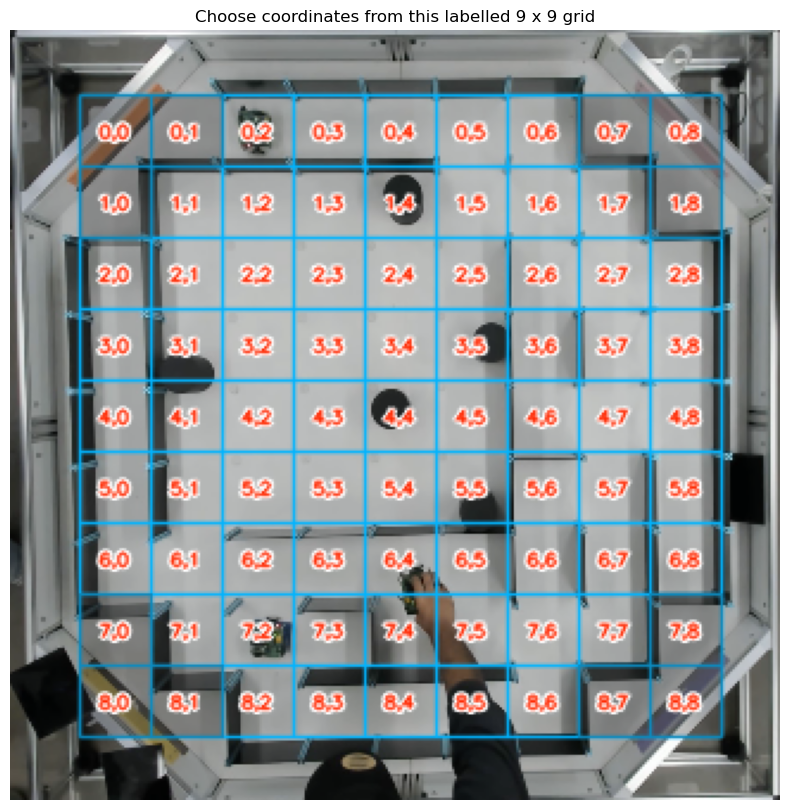

In [3]:
mapping_preview = prepare_mapping_preview(preview_config)
plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(mapping_preview.coordinate_grid_bgr, cv2.COLOR_BGR2RGB))
plt.title('Choose coordinates from this labelled 9 x 9 grid')
plt.axis('off')
plt.show()

## Phase 2: manually enter the cells and plan

Staff confirmed the 5 x 5 entrance and exit may be programmed. Enter both sides of each doorway: `inside_cell` must be inside the 5 x 5 obstacle area and `outside_cell` must be the neighbouring normal-maze cell. The two cells must share one side.

The values below are an example for the current `maze2.png`; verify them against the labelled grid. Headings are east `0`, north `90`, west `180`, south `-90`.

In [4]:
OBSTACLE_TOP_LEFT = (1, 1)
OBSTACLE_SIZE = 5

START = (0, 2)
GOAL = (6, 0)
INITIAL_HEADING_DEG = 90.0
GOAL_HEADING_DEG = None

# ENTRANCE_OUTSIDE = (6, 1)
# ENTRANCE_INSIDE = (5, 1)
# EXIT_INSIDE = (1, 5)
# EXIT_OUTSIDE = (0, 5)
EXIT_OUTSIDE = (6, 1)
EXIT_INSIDE = (5, 1)
ENTRANCE_INSIDE = (1, 5)
ENTRANCE_OUTSIDE = (0, 5)

CONFIG = DemoConfig(
    image_file=IMAGE_FILE,
    output_pixels=OUTPUT_PIXELS,
    board_corners=BOARD_CORNERS,
    grid_bounds=GRID_BOUNDS,
    obstacle_top_left=OBSTACLE_TOP_LEFT,
    obstacle_size=OBSTACLE_SIZE,
    entrance=Portal(outside_cell=ENTRANCE_OUTSIDE, inside_cell=ENTRANCE_INSIDE),
    exit=Portal(outside_cell=EXIT_OUTSIDE, inside_cell=EXIT_INSIDE),
    start=START,
    goal=GOAL,
    initial_heading_deg=INITIAL_HEADING_DEG,
    goal_heading_deg=GOAL_HEADING_DEG,
    robot_radius_mm=30.0,  # replace with measured centre-to-furthest-corner
    safety_margin_mm=5.0,
    obstacle_resolution_mm=5.0,
    obstacle_distance_scale=1000.0 / 1018.2,  # measured drive calibration
    rrt_max_waypoint_spacing_mm=150.0,  # increase for fewer blue dots; decrease for more
)

## Execute both maps and all three planning stages

In [5]:
result = run_two_map_demo(CONFIG)

print('Stage 1 - normal cell graph:', result.route.normal_before_cells)
print('Stage 2 - continuous obstacle RRT*:', result.route.obstacle_result.status.value)
print('Stage 3 - normal cell graph:', result.route.normal_after_cells)
print('Detected obstacle centres in crop:', result.obstacle_map.detected_centres)

Stage 1 - normal cell graph: [(0, 2), (0, 3), (0, 4), (0, 5), (1, 5)]
Stage 2 - continuous obstacle RRT*: success
Stage 3 - normal cell graph: [(5, 1), (6, 1), (6, 0)]
Detected obstacle centres in crop: [(127, 18), (19, 104), (120, 122)]


## Task 1 mask confirmation

This is the overlay returned directly by `mazemapping.mask_maze.create_maze_masks()`. It is shown for verification, but the normal planner samples expected cell boundaries instead of treating the entire red image as a continuous occupancy grid.

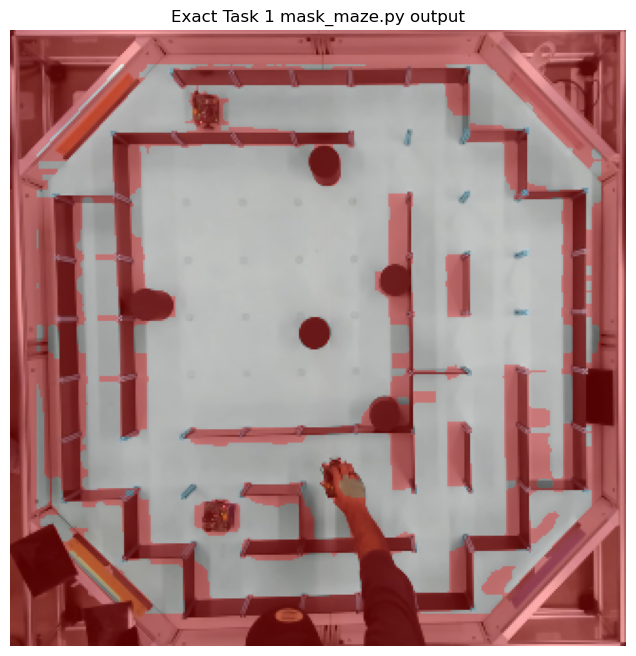

In [6]:
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result.task1_masks['08_mask_overlay.png'], cv2.COLOR_BGR2RGB))
plt.title('Exact Task 1 mask_maze.py output')
plt.axis('off')
plt.show()

## The two independent maps

Left: the normal 9 x 9 cell graph with the 5 x 5 interior excluded except its two portals. Blue and magenta are the normal routes.

Right: only the 5 x 5 continuous crop. Red is detected cylinders/boundary, amber is robot clearance, and green is the RRT* route.

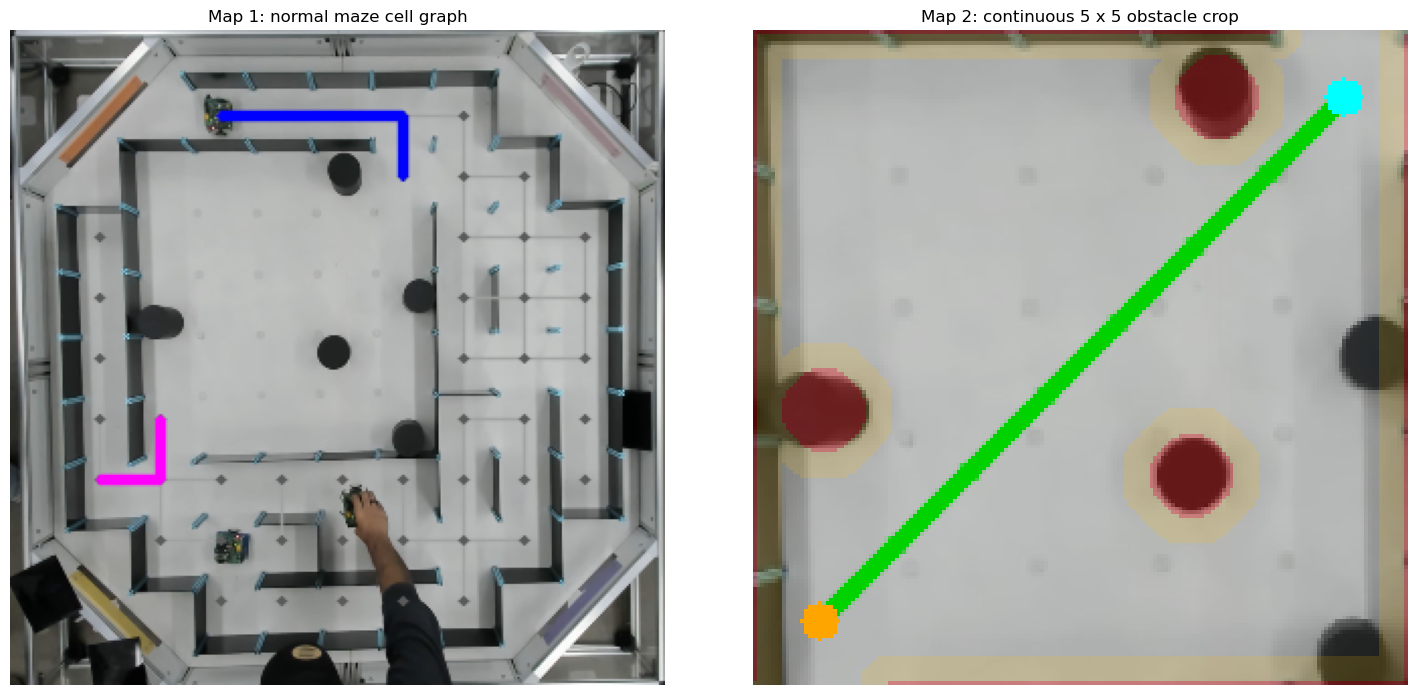

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(cv2.cvtColor(result.normal_preview_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Map 1: normal maze cell graph')
axes[1].imshow(cv2.cvtColor(result.obstacle_preview_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title('Map 2: continuous 5 x 5 obstacle crop')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()

## Complete joined path on the original camera image

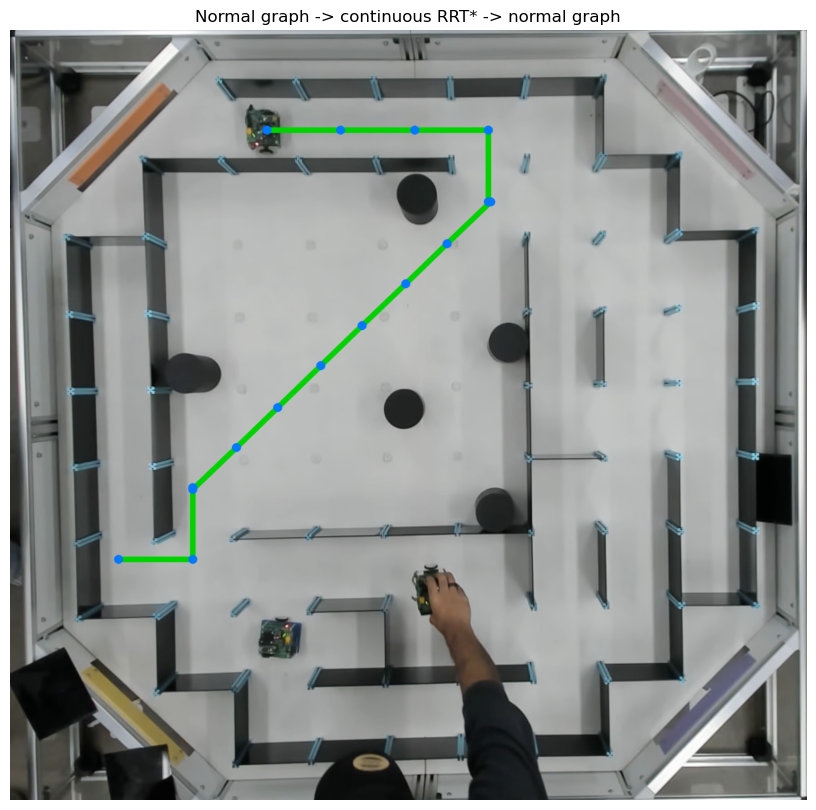

In [8]:
plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(result.original_preview_bgr, cv2.COLOR_BGR2RGB))
plt.title('Normal graph -> continuous RRT* -> normal graph')
plt.axis('off')
plt.show()

In [9]:
print('Hybrid command:')
print(result.route.command)

Hybrid command:
"rfffrf,[(-45.0,145.8),(0.0,138.9),(0.0,145.8),(0.0,138.9),(0.0,145.8),(0.0,138.9),(0.0,145.8),(45.0,0.0)],frf";
